# Reinforcement Learning Controller

## Overview

First-principles models capture the main behavior of most engineered systems, but they are never exact. The gap between the model and reality comes from uncertain parameters, unmodeled nonlinear effects, coupling effects, and external disturbances. These factors limit the performance of purely model-based controllers. This notebook presents an adaptive control framework with learned uncertainty compensation, implemented in `[1]`. The framework addresses that gap with a composite control law:

$$
u = u_{\text{model}} + u_{\text{learned}}
$$

- $u_{\text{model}}$: a backstepping controller derived from the nominal model, providing baseline stability
- $u_{\text{learned}}$: an actor–critic reinforcement learning network that 
  compensates the residual online, without requiring the uncertainty to be 
  known in advance

The model remains the backbone while the reinforcement learning component learns only what the model cannot explain. A 2-DOF helicopter serves as the worked example implemented in [c4dynamics](https://c4dynamics.github.io/c4dynamics/).

## 1. Learning Controller

This notebook implements an **Actor–Critic Reinforcement Learning architecture** with state constraints, which has four main components:

- **RBF Neural Networks**: radial basis function neural networks are used to approximate unknown system dynamics, enabling the controller to compensate for uncertainties without requiring an explicit model
- **Critic Network**: the critic network evaluates the quality of the control performance by estimating a long-term cost function
- **Actor Network**: the actor network generates control inputs that aim to minimize this cost
- **Barrier Lyapunov Function**: the barrier function is incorporated to enforce state constraints by penalizing trajectories that approach unsafe regions. This combination of learning, approximation, and stability-based design results in a unified control strategy that is both flexible and robust.

- Import required libraries

In [53]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
import c4dynamics as c4d

### Radial Basis Function Neural Networks (RBFNNs)

Radial Basis Function Neural Networks are a class of function approximators that are widely used in adaptive control due to their simplicity and strong approximation capabilities. An RBFNN represents a nonlinear function as a weighted sum of radial basis functions, typically Gaussian functions centered at different points in the input space. Because of their localized response, these networks can approximate complex nonlinear mappings with relatively simple structures and fast training.

In this work, both the critic and actor use Radial Basis Function Neural Networks (RBFNNs) as linear-in-weights function approximators:

$$
f(Z) = W^T H(Z) 
$$
$$
h_i(Z) = \exp\left(-\frac{\|Z - c_i\|^2}{b^2}\right)
$$

- `rbf_basis()` computes the radial basis function activations $𝐻(𝑍)$ for a given input vector $𝑍$, set of centers $𝑐_𝑖$, and Gaussian width $𝑏$, enabling nonlinear function approximation through localized basis functions

In [54]:
def rbf_basis(Z: np.ndarray, centers: np.ndarray, width: float) -> np.ndarray:
    diff = Z - centers
    return np.exp(-np.sum(diff**2, axis=1) / width**2)

- `rbf_gradient()` evaluates the gradient of Gaussian RBFs $\nabla H(Z)$ with respect to the input vector, used in computing learning signals and temporal-difference updates

In [55]:
def rbf_gradient(Z: np.ndarray, centers: np.ndarray,
                 width: float, H: np.ndarray) -> np.ndarray:
    diff = Z - centers
    return H[:, None] * (-2.0 * diff / width**2)

- `make_centers()` constructs a set of RBF centers $c_i$ over the state/input domain, enabling localized Gaussian basis functions for accurate nonlinear function approximation

In [56]:
def make_centers(n_nodes: int, input_dim: int,
                 bounds: list, rng: np.random.Generator) -> np.ndarray:
    lo = np.array([b[0] for b in bounds])
    hi = np.array([b[1] for b in bounds])
    return rng.uniform(0, 1, size=(n_nodes, input_dim)) * (hi - lo) + lo

###  Critic

The critic network plays a central role in the reinforcement learning framework by estimating a long-term cost function that reflects the quality of the control performance over time. By approximating this function using a neural network, the critic can evaluate how good a particular control policy is and provide feedback to guide improvement. The learning process is based on minimizing the difference between the predicted and actual cost evolution, allowing the critic to refine its estimate as the system evolves.

Computes instantaneous cost $I(t) = z_1^T Q z_1 + u^T R u$, forms the temporal-difference residual $\phi$, and updates critic weights $W_c$ by gradient descent. It finally returns the estimated cost-to-go $\hat{J}$.

In [57]:
def critic_update(Wc: np.ndarray,
                  Hc: np.ndarray, grad_Hc: np.ndarray,
                  z1: np.ndarray, z2: np.ndarray,
                  u: np.ndarray,
                  Q: np.ndarray, R: np.ndarray,
                  zeta: float, lc: float, dt: float):

    I_t    = float(z1 @ Q @ z1 + u @ R @ u)
    z1_dot = z2
    Lambda = -Hc / zeta + grad_Hc @ z1_dot
    phi    = I_t + Wc @ Lambda
    Wc     = Wc - lc * phi * Lambda * dt
    J_hat  = float(Wc @ Hc)

    return Wc, J_hat

### Actor

The actor network is responsible for generating the control input based on the current system state and the information provided by the critic. Its objective is to produce actions that minimize the long-term cost estimated by the critic, effectively improving control performance over time. In this work, the actor incorporates both the backstepping-based control structure and the neural network approximation of unknown dynamics, resulting in a control law that is both adaptive and learning-driven. The actor’s parameters are updated using a gradient-based rule that considers states, inputs and the critic’s evaluation, enabling the controller to balance immediate performance with long-term optimization.

####  Backstepping

Backstepping is a recursive control design technique commonly used for nonlinear systems, where the control problem is broken down into a sequence of smaller steps.  
Instead of directly designing the final control input, the method first introduces intermediate or "virtual" control laws that stabilize lower-order subsystems, and then progressively builds toward the actual control input.  
The main advantage of backstepping is that it provides a systematic way to handle nonlinearities while maintaining rigorous stability guarantees.

Compute backstepping error signals and the virtual control α.


$$
z_1 = x_1 - x_d \\

\alpha = -K_1 \cdot z_1 + \dot{x}_d \\

z_2 = x_2 - \alpha \\
 
\dot{\alpha} = -K_1 \cdot (x_2 - \dot{x}_d) + \ddot{x}_d
$$


In [58]:
def backstepping(x1: np.ndarray, x2: np.ndarray,
                 xd: np.ndarray, xd_d: np.ndarray,
                 xd_dd: np.ndarray, K1: np.ndarray):

    z1      = x1 - xd
    alpha   = -K1 @ z1 + xd_d
    z2      = x2 - alpha
    alpha_d = -K1 @ (x2 - xd_d) + xd_dd

    return z1, z2, alpha_d

####  Barrier Lyapunov Function (BLF)

To ensure that the system states remain within predefined safety limits, a barrier Lyapunov function is introduced into the control design. Unlike standard Lyapunov functions, which typically penalize large errors, the barrier Lyapunov function becomes unbounded as the system approaches constraint boundaries, effectively preventing the states from violating these limits. This creates a virtual "barrier" that restricts the evolution of the system within a safe region. In practice, this means that the control input increases sharply as the tracking error approaches the constraint boundary, forcing the system back toward the allowable region. This mechanism is particularly important in reinforcement learning settings, where exploration may otherwise lead to unsafe behavior. For this, the control signal is computed as:
 
$$
BLF_{term_{i}} = z_{1i} / (kb_i^2 − z_{1i}^2)
$$

$$
P = GG^T + \omega I
$$

$$
u = G^T P^{-1} (−BLF_{term} − K_2 z_2 − F − \hat{Wa}^T H_a + \alpha_d)
$$

Where: 


In [59]:
def rlc_blf_control(z1: np.ndarray, z2: np.ndarray,
                    F: np.ndarray, G: np.ndarray,
                    Wa: np.ndarray, Ha: np.ndarray,
                    alpha_d: np.ndarray,
                    K2: np.ndarray, omega: float,
                    kb: np.ndarray) -> np.ndarray:

    z1_safe  = np.clip(z1, -0.999 * kb, 0.999 * kb)
    blf_term = z1_safe / (kb**2 - z1_safe**2)

    P   = G @ G.T + omega * np.eye(2)
    rhs = -blf_term - K2 @ z2 - F - Wa.T @ Ha + alpha_d
    return G.T @ np.linalg.solve(P, rhs)

- Updates actor weights using $\dot{\hat{W}}_a = -l_a · H_a · ( \hat{W_a}^T H_a + K_J \hat{J})^T$, improving control policy based on performance feedback

In [60]:
def actor_update(Wa: np.ndarray,
                 Ha: np.ndarray,
                 J_hat: float,
                 KJ: np.ndarray,
                 la: float, dt: float):

    inner = Wa.T @ Ha + KJ * J_hat
    dWa   = -la * np.outer(Ha, inner)

    return Wa + dWa * dt

### Controller Parameters

- Define controller parameters

In [61]:
# Controller gains
K1    = np.diag([30.0, 30.0]) # Position error gain
K2    = np.diag([15.0, 4.0])  # Velocity error gain
kb    = np.array([0.03, 0.8]) # BLF barrier bounds for θ, ψ errors
omega = 0.01                  # P-matrix regulariser

# RLC / NN hyper-parameters
lc   = 1.0                       # critic learning rate
la   = 3.0                       # actor learning rate
bc   = 0.5                       # critic Gaussian width
ba   = 2.0                       # actor Gaussian width
Nc   = 32                        # critic hidden nodes
Na   = 64                        # actor hidden nodes
KJ   = np.array([10.0, 10.0])   # critic influence on actor
Q    = 0.1 * np.eye(2)          # state cost matrix
R    = 0.1 * np.eye(2)          # input cost matrix
zeta = 50.0                      # cost discount factor

# RBFNN centre bounds
critic_bounds = [(-0.04, 0.04), (-1.0, 1.0)]
actor_bounds  = [(-0.3, 0.3), (-0.3, 0.3),
                  (-1.0, 1.0), (-1.0, 1.0),
                  (-5.0, 5.0), (-5.0, 5.0)]


## 2. Simulation Environment

The controller assumes systems of the form:

$$
\dot{x}_1 = x_2
$$
$$
\dot{x}_2 = F(x) + G(x)\, u
$$

where the full state vector is $x = [x_1,\, x_2] \in \mathbb{R}^{2n}$, split into:

- $x_1 \in \mathbb{R}^n$ (e.g., positions or angles)  
- $x_2 \in \mathbb{R}^n$ (e.g., rates or velocities) 

and:

- $F(x) \in \mathbb{R}^n$ : system internal dynamics
- $G(x) \in \mathbb{R}^{n \times m}$: control-input matrix
- $u \in \mathbb{R}^m$: control input vector

Here $n$ is the number of generalized coordinates and $m$ is the number of inputs. To plug in a new system into this controller, implement a class with these methods and information:

|  | Description |
|---|---|
| `states` | System states |
| `system parameters` | Specify all the system parameters |
| `F(x)` | System internal dynamics |
| `G(x)` | Control-input matrix |
| `dynamics(t, x, u)` | Full state derivative for numerical integration |
| `reference(t)` | Desired trajectory and its first two derivatives |

This a pseudocode that serves as an example. For a full detailed example, you can refer to the helicopter environment example.

```python
class MySystem:

    # State variables
    state 1: float
    ...
    state_n: float

    dstate_1: float
    ...
    dstate_n: float

    
    # Define physical/model parameters
    parameter_1 = ...
    parameter_2 = ...
    ...

    # Initialize states
    def __init__(self, state_1=state_1_0 , ..., dstate_1=dstate_1_0, ...):

    # Internal dynamics
    def F(self, x):
        return F

    # Input matrix
    def G(self, x):
        return G

    # Full state equation
    def dynamics(self, t, x, u):

        x1_dot = x2
        x2_dot = F(x) + G(x) @ u

        return [x1_dot, x2_dot]

    # Desired trajectory
    def reference(self, t):

        xd     = ...
        xd_dot = ...
        xd_ddot = ...

        return xd, xd_dot, xd_ddot

## 3.  Helicopter example

### System Dynamics

The system under consideration is a laboratory-scale 2-DOF helicopter, which can rotate in pitch and yaw directions and is actuated by two independent DC motors generating thrust forces. The system exhibits strong nonlinear coupling between these two axes. These characteristics make the control problem particularly challenging, as the controller must handle nonlinearities, coupling effects, and incomplete knowledge of the system while maintaining stable and accurate trajectory tracking.

<div style="text-align: center;">
  <img src="helicopter_diagram.png" alt="alt text" style="width: 50%;">
  <figcaption>Figure 1: Helicopter diagram</figcaption>
</div>

The dynamics are derived using Lagrangian mechanics and result in a nonlinear multi-input multi-output (MIMO) system.  
The 2-DOF helicopter system equations of motion can be written as `[1]`:

$$
(J_p + M \cdot L_{cm}^2) \cdot \ddot{\theta} = K_{pp} \cdot V_p + K_{py} \cdot V_y - M \cdot g \cdot L_{cm} \cdot \cos(\theta) - D_p \cdot \dot{\theta} - M \cdot L_{cm}^2 \cdot \dot{\psi}^2 \cdot \sin(\theta) \cdot \cos(\theta)
$$
 
$$
(J_y + M \cdot L_{cm}^2 \cdot \cos^2(\theta)) \cdot \ddot{\psi} = K_{yp} \cdot V_p + K_{yy} \cdot V_y - D_y \cdot \dot{\psi} + 2 \cdot M \cdot L_{cm}^2 \cdot \dot{\psi} \cdot \dot{\theta} \cdot \sin(\theta) \cdot \cos(\theta)
$$

where: 
- $\theta, \psi, \dot{\theta}, \dot{\psi}$: form the system state and are denoted as pitch angle, yaw angle, pitch angular velocity, and yaw angular velocity, respectively
- $V_p, V_y$: input voltages of the two motors, respectively
- $D_p, D_y$: viscous friction constants of pitch and yaw, respectively
- $J_p, J_y$: moments of inertia of the pitch axis and yaw axis, respectively
- $K_{pp}, K_{py}, K_{yp}, K_{yy}$: torque thrust gains acting on the pitch axis from the pitch propeller, pitch axis from the yaw propeller, yaw axis from the pitch propeller, and yaw axis from the yaw propeller, respectively
- $g$: the gravitational acceleration
- $L_{cm}$: the center-of-mass distance from the body-fixed frame origin
- $M$: the helicopter's mass

The state variables are defined as $ x = [\theta, \psi, \dot{\theta}, \dot{\psi}]^T$. For this example, $n = 2$ (pitch and yaw) and $m = 2$ (pitch motor voltage, yaw motor voltage), therefore, $x_1 = [\theta, \psi]$ and $x_2 = [\dot{\theta}, \dot{\psi}]$.

- Define initial states

In [62]:
theta0 = 0.0  # [rad]
psi0 = 0.0  # [rad]
thetadot0 = 0.0  # [rad/s]
psidot0 = 0.0  # [rad/s]

- Import environment

In [63]:
from environments import helicopter

env = helicopter(theta=theta0, psi=psi0, dtheta=thetadot0, dpsi=psidot0)
print(env)
print(env.X)

[ θ  ψ  dtheta  dpsi ]
[0. 0. 0. 0.]


- Desired setpoint

The desired trajectory used in this study consists of smooth sinusoidal functions for both pitch and yaw angles, which are commonly used in control system validation. This type of trajectory is particularly suitable because it continuously excites the system dynamics, allowing the controller’s performance to be evaluated under varying conditions rather than at a single operating point.

$$
x_d(t) =
\begin{bmatrix}
\frac{10\pi}{180} \sin(t) \\
\\
\frac{15\pi}{180} \cos(t)
\end{bmatrix}
\quad [\text{rad}]
$$

$$
\dot{x}_d(t) =
\begin{bmatrix}
\frac{10\pi}{180} \cos(t) \\
\\
-\frac{15\pi}{180} \sin(t)
\end{bmatrix}
\quad [\text{rad/s}]
$$

$$
\ddot{x}_d(t) =
\begin{bmatrix}
-\frac{10\pi}{180} \sin(t) \\
\\
-\frac{15\pi}{180} \cos(t)
\end{bmatrix}
\quad [\text{rad/s}^2]
$$

### Simulation

For each step:

1. Read env.X    
2. Compute z1, z2, F, G
3. Update Wc (critic)
4. Update Wa (actor)
5. Compute input u
6. Solve_ivp
7. Update env.X states
8. Log data for plotting

In [64]:
u_hist = []

def run_rlc(dt: float = 0.001, T: float = 25.0, seed: int = 42):
    # RBFNN centre placement
    rng = np.random.default_rng(seed)

    # Critic input: Zc = z1, bounded by barrier kb
    critic_centers = make_centers(Nc, 2, critic_bounds, rng)

    # Actor input: Za = [x1, x2, u]
    actor_centers  = make_centers(Na, 6, actor_bounds, rng)

    # Weight initialisation
    Wc = np.zeros(Nc)
    Wa = np.zeros((Na, 2))
    u  = np.zeros(2)

    # Log initial state
    # t = 0.0
    # heli.store(t)
    # heli.storeparams('Vpitch', t=t)
    # heli.storeparams('Vyaw', t=t)

    # Main control loop
    # N_steps = int(T / dt)

    # for _ in range(N_steps):
    for t in np.arange(0, T, dt):

        # heli.store(t)
        # heli.storeparams('Vpitch', t=t)
        # heli.storeparams('Vyaw', t=t)

        env.store(t)
        u_hist.append(u.copy())



        # x1 = heli.X[:2]
        # x2 = heli.X[2:]

        # if np.any(heli.X != env.X):
        #     c4d.cprint(f'{_} - State mismatch between defined and environment states!')

        # Reference trajectory
        xd, xd_d, xd_dd = env.reference(t)

        # Backstepping error variables
        z1, z2, alpha_d = backstepping(env.X[:2], env.X[2:], xd, xd_d, xd_dd, K1)


        # Dynamics matrices
        # F, G = helicopter_dynamics_matrices(x1, x2)
        # F, G = env.F(), env.G()

        # if np.any(F != F_env) or np.any(G != G_env):
        #     c4d.cprint(f'{_} - Dynamics mismatch between defined and environment matrices!')



        # Critic NN
        Hc      = rbf_basis(z1, critic_centers, bc)
        grad_Hc = rbf_gradient(z1, critic_centers, bc, Hc)
        Wc, J_hat = critic_update(Wc, Hc, grad_Hc, z1, z2, u, Q, R, zeta, lc, dt)

        # Actor NN
        Za = np.concatenate([env.X, u])
        Ha = rbf_basis(Za, actor_centers, ba)
        Wa = actor_update(Wa, Ha, J_hat, KJ, la, dt)

        # Compute control signal using RLC_BLF control law
        u = rlc_blf_control(z1, z2, env.F(), env.G(), Wa, Ha, alpha_d, K2, omega, kb)

        # # Integrate ODE
        # sol = solve_ivp(
        #     helicopter_dynamics,
        #     [t, t + dt],
        #     heli.X,
        #     # args=([heli.Vpitch, heli.Vyaw],),
        #     args=(u,),
        #     method='RK45',
        #     max_step=dt,
        #     rtol=1e-6,
        #     atol=1e-9
        # )

        # Integrate ODE
        sol_env = solve_ivp(
            env.dynamics,
            [t, t + dt],
            env.X,
            # args=([env.Vpitch, env.Vyaw],),
            args=(u,),
            method='RK45',
            max_step=dt,
            rtol=1e-6,
            atol=1e-9
        )

        # if np.any(sol.y[:, -1] != sol_env.y[:, -1]):
        #     c4d.cprint(f'{_} - State mismatch between defined and environment ODE solutions!')

        # Update states
        # t     += dt
        # heli.X = sol.y[:, -1]
        env.X  = sol_env.y[:, -1]

        # Log states and inputs
        # heli.Vpitch = u[0]
        # heli.Vyaw = u[1]

        # env.Vpitch = u[0]
        # env.Vyaw = u[1]


### Results

#### Plotting

In [65]:
def plot_results(env: c4d.state):

    t_hist, theta_hist = env.data('theta')
    _,       psi_hist  = env.data('psi')

    # Compute desired trajectory over the logged time grid
    theta_d = np.array([env.reference(ti)[0][0] for ti in t_hist])
    psi_d   = np.array([env.reference(ti)[0][1] for ti in t_hist])

    # Tracking errors
    z11 = theta_hist - theta_d
    z12 = psi_hist   - psi_d

    def _style(ax, ylabel='', title=''):
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel(ylabel,     fontsize=9)
        ax.set_title(title,       fontsize=10, fontweight='bold')
        ax.set_xlim(0, 25)
        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc='upper right')

    # Tracking trajectories
    fig1 = plt.figure(figsize=(10, 8))
    fig1.suptitle('State and Control inputs',
                  fontsize=12, fontweight='bold')
    gs = GridSpec(3, 1, hspace=0.45)

    ax = fig1.add_subplot(gs[0])
    ax.plot(*env.data('theta'), 'r-',  lw=1.2, label=r'$	\theta$')
    ax.plot(t_hist, theta_d,    'b--', lw=1.0, label=r'$	\theta_d$')
    ax.set_ylim(-0.5, 0.5)
    _style(ax, ylabel='Angle [rad]', title=r'(a) Pitch angle $	\theta$')

    ax = fig1.add_subplot(gs[1])
    ax.plot(*env.data('psi'), 'r-',  lw=1.2, label=r'$\psi$')
    ax.plot(t_hist, psi_d,    'b--', lw=1.0, label=r'$\psi_d$')
    ax.set_ylim(-0.5, 0.5)
    _style(ax, ylabel='Angle [rad]', title=r'(b) Yaw angle $\psi$')

    Vpitch, Vyas = np.array(u_hist).T

    ax = fig1.add_subplot(gs[2])
    ax.plot(t_hist, Vpitch, 'r-', lw=1.0, label=r'$u_1$')
    ax.plot(t_hist, Vyas, 'b-', lw=1.0, label=r'$u_2$')
    _style(ax, ylabel='Voltage [V]', title='(c) Control inputs u')
    plt.show()

    # Tracking errors
    fig2 = plt.figure(figsize=(10, 5))
    fig2.suptitle('Tracking Errors',
                  fontsize=12, fontweight='bold')
    gs2 = GridSpec(1, 2, hspace=0.35, wspace=0.35)

    ax = fig2.add_subplot(gs2[0])
    ax.plot(t_hist, z11, 'b-', lw=1.0, label=r'$z_{11}$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-0.09, 0.09)
    _style(ax, ylabel='Error [rad]', title=r'(a) Pitch error $z_{11}$')

    ax = fig2.add_subplot(gs2[1])
    ax.plot(t_hist, z12, 'b-', lw=1.0, label=r'$z_{12}$')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-0.6, 0.6)
    _style(ax, ylabel='Error [rad]', title=r'(b) Yaw error $z_{12}$')
    plt.show()

#### Running the Simulation

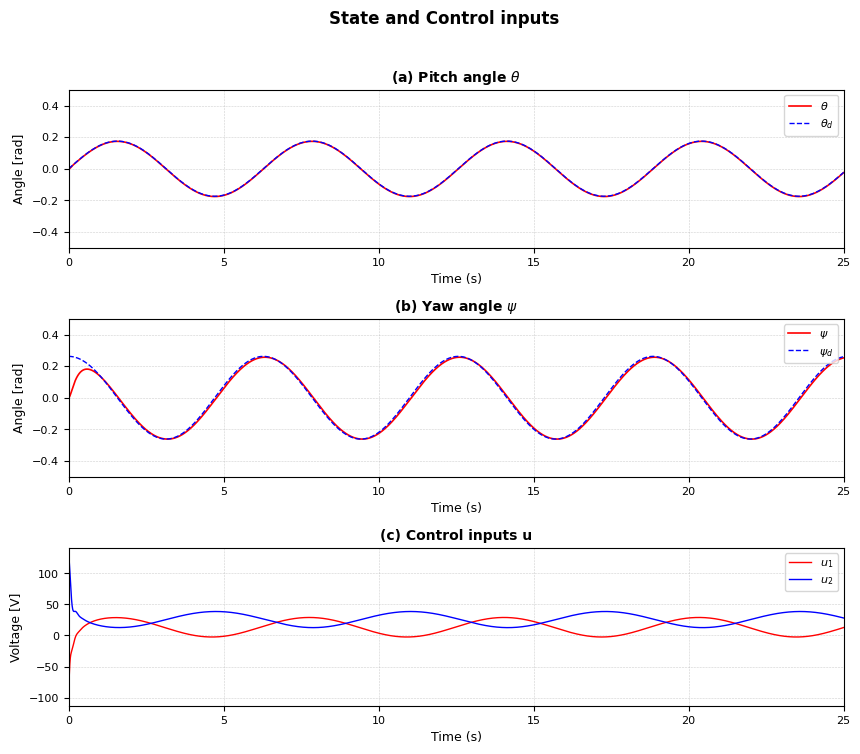

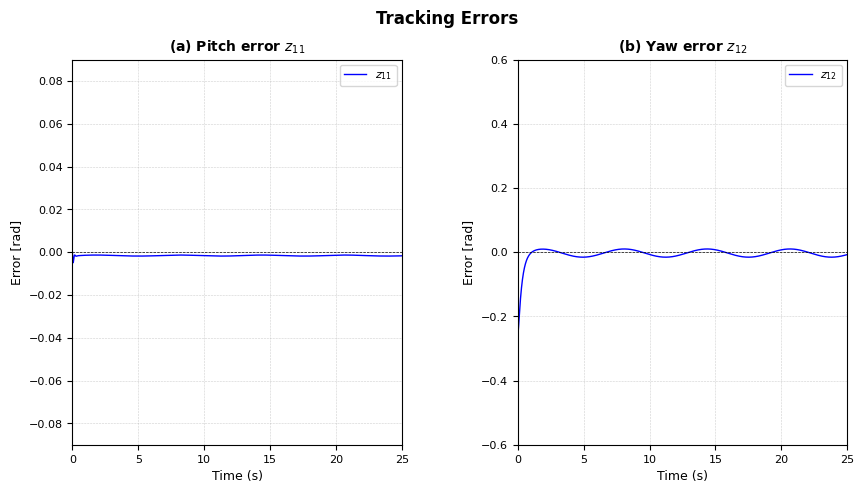

In [66]:
DT = 0.001    # integration step [s]
T  = 25.0     # simulation duration [s]

# heli = run_rlc(dt=DT, T=T, seed=42)
# plot_results(heli)

run_rlc(dt = DT, T = T, seed = 42)

plot_results(env)

## References

[1] Zhao et al., "Reinforcement Learning Control for a 2-DOF Helicopter With State Constraints: Theory and Experiments" IEEE Trans. Autom. Sci. Eng., Vol. 21, No. 1, Jan 2024. [DOI: 10.1109/TASE.2022.3215738](https://cogno.pusan.ac.kr/sites/cogno/2024/2024_260.pdf)